[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\girma\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


Current working directory: c:\new_analysis_project\notebooks
Columns in dataset: ['Unnamed: 0', 'headline', 'url', 'publisher', 'date', 'stock']

Headline Length Statistics:
count    1.407328e+06
mean     7.312051e+01
std      4.073531e+01
min      3.000000e+00
25%      4.700000e+01
50%      6.400000e+01
75%      8.700000e+01
max      5.120000e+02
Name: headline_length, dtype: float64

Articles per Publisher:
publisher
Paul Quintaro        228373
Lisa Levin           186979
Benzinga Newsdesk    150484
Charles Gross         96732
Monica Gerson         82380
Eddie Staley          57254
Hal Lindon            49047
ETF Professor         28489
Juan Lopez            28438
Benzinga Staff        28114
Name: count, dtype: int64


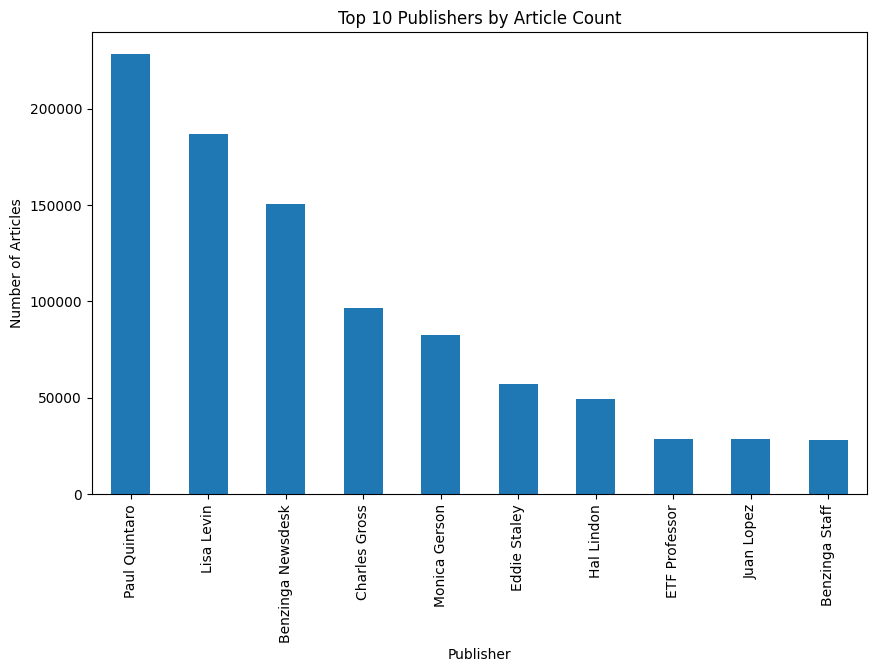

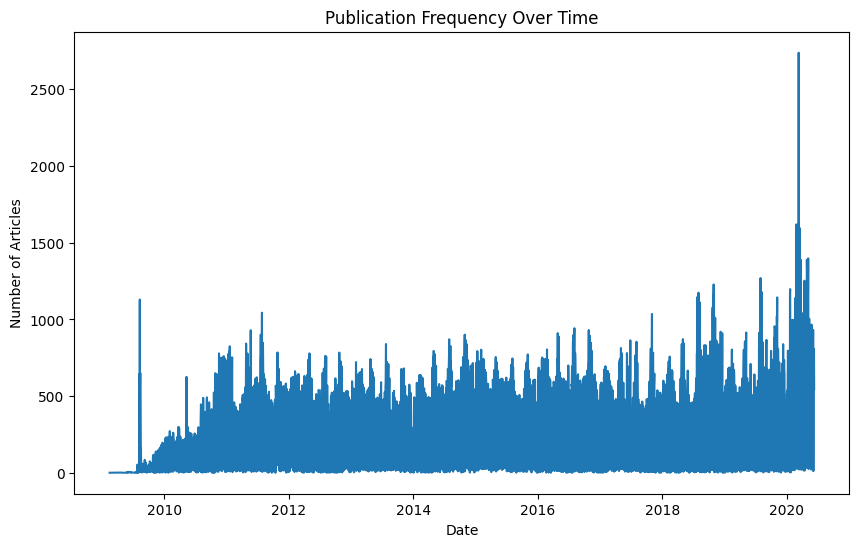

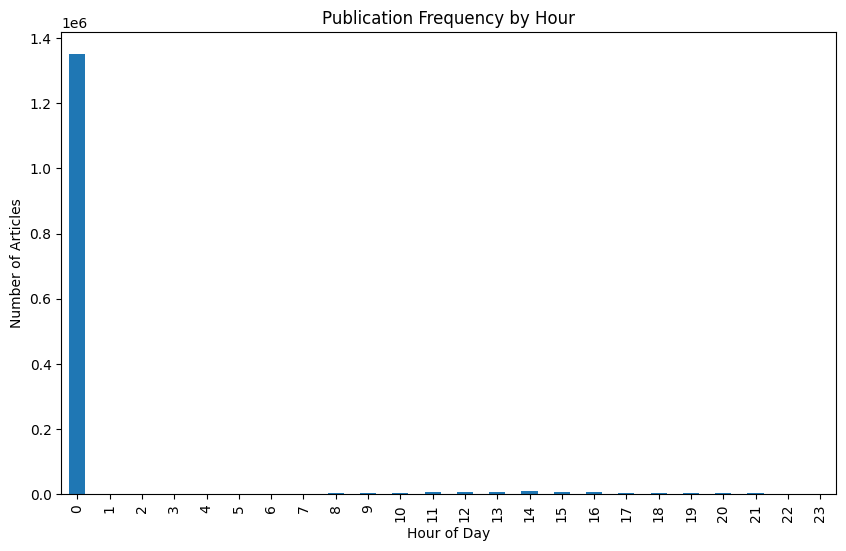

KeyboardInterrupt: 

In [13]:
import pandas as pd
import os

# Confirm current working directory
print("Current working directory:", os.getcwd())

# Set paths
project_root = 'C:/new_analysis_project'
data_dir = os.path.join(project_root, 'data')
notebooks_dir = os.path.join(project_root, 'notebooks')

# Load data
df = pd.read_csv(os.path.join(data_dir, 'raw_analyst_ratings.csv'))
print("Columns in dataset:", df.columns.tolist())

# Descriptive Statistics: Headline length
df['headline_length'] = df['headline'].apply(len)
print("\nHeadline Length Statistics:")
print(df['headline_length'].describe())

# Articles per publisher
publisher_counts = df['publisher'].value_counts()
print("\nArticles per Publisher (Top 10):")
print(publisher_counts.head(10))

# Basic date analysis: Count articles per date
df['date'] = pd.to_datetime(df['date'], format='mixed', utc=True, errors='coerce')
if df['date'].isna().any():
    print(f"Warning: {df['date'].isna().sum()} invalid dates were set to NaN.")
df['date_only'] = df['date'].dt.date
date_counts = df['date_only'].value_counts().sort_index()
print("\nArticles per Date (Top 10):")
print(date_counts.head(10))

Current working directory: c:\new_analysis_project\notebooks
Columns in dataset: ['Unnamed: 0', 'headline', 'url', 'publisher', 'date', 'stock']

Headline Length Statistics:
count    1.407328e+06
mean     7.312051e+01
std      4.073531e+01
min      3.000000e+00
25%      4.700000e+01
50%      6.400000e+01
75%      8.700000e+01
max      5.120000e+02
Name: headline_length, dtype: float64

Articles per Publisher (Top 10):
publisher
Paul Quintaro        228373
Lisa Levin           186979
Benzinga Newsdesk    150484
Charles Gross         96732
Monica Gerson         82380
Eddie Staley          57254
Hal Lindon            49047
ETF Professor         28489
Juan Lopez            28438
Benzinga Staff        28114
Name: count, dtype: int64

Articles per Date (Top 10):
date_only
2009-02-14    1
2009-04-27    2
2009-04-29    1
2009-05-22    1
2009-05-27    6
2009-05-29    2
2009-05-30    3
2009-06-01    5
2009-06-02    2
2009-06-05    6
Name: count, dtype: int64


In [14]:
import pandas as pd
import nltk
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation
import os

# Download NLTK stopwords
nltk.download('stopwords')
from nltk.corpus import stopwords

# Confirm current working directory
print("Current working directory:", os.getcwd())

# Set paths
project_root = 'C:/new_analysis_project'
data_dir = os.path.join(project_root, 'data')
notebooks_dir = os.path.join(project_root, 'notebooks')

# Load data (sample for performance)
df = pd.read_csv(os.path.join(data_dir, 'raw_analyst_ratings.csv')).sample(10000, random_state=42)
print("Columns in dataset:", df.columns.tolist())

# Text Analysis: Topic modeling on headlines
if 'headline' in df.columns:
    stop_words = stopwords.words('english')
    vectorizer = CountVectorizer(stop_words=stop_words, max_df=0.95, min_df=2)
    X = vectorizer.fit_transform(df['headline'].dropna())
    lda = LatentDirichletAllocation(n_components=5, random_state=42)
    lda.fit(X)
    feature_names = vectorizer.get_feature_names_out()
    for topic_idx, topic in enumerate(lda.components_):
        print(f"\nTopic {topic_idx + 1}:")
        print(" ".join([feature_names[i] for i in topic.argsort()[-10:]]))
else:
    print("Column 'headline' not found. Skipping text analysis.")

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\girma\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


Current working directory: c:\new_analysis_project\notebooks
Columns in dataset: ['Unnamed: 0', 'headline', 'url', 'publisher', 'date', 'stock']

Topic 1:
coverage initiates announces 00 maintains buy target raises price pt

Topic 2:
higher mid companies day trading moving session market shares stocks

Topic 3:
offering share co biggest stock reports shares movers says announces

Topic 4:
markets etfs morning downgrades mid upgrades update top market benzinga

Topic 5:
estimate 52 earnings week sales reports stocks eps est vs
